# SpatioEv Tutorial 01: Clustering-Based Phenotyping

This tutorial follows the same core logic as the ST_Pat4_51 phenotyping notebook, but keeps the workflow compact:

1. Specify the marker panel for level-0 unsupervised clustering.
2. Run PCA, nearest-neighbor graph construction, UMAP, and Leiden clustering with SpatioEv.
3. Review marker enrichment and overlay raw clusters on the original image.
4. Decide cluster identities and assign labels interactively.
5. Optionally subset a broad population, recluster it with its own marker panel, overlay subclusters on the image, and merge refined labels back.


## Setup And Example Data


In [1]:
from pathlib import Path
import importlib.util

import matplotlib.pyplot as plt
import pandas as pd

import spatioev as sv

ROOT = Path.cwd()
if not (ROOT / "spatioev").exists():
    for candidate in ROOT.parents:
        if (candidate / "spatioev").exists():
            ROOT = candidate
            break

DATA_DIR = ROOT / "data"
BACKGROUND_DIR = ROOT / "background"
RESULT_DIR = ROOT / "results"
RESULT_DIR.mkdir(exist_ok=True)

EXP1_H5AD = DATA_DIR / "exp_1" / "exp_1.h5ad"
ANNOTATION_PATH = RESULT_DIR / "phenotyping_annotations.csv"

ORIGINAL_IMAGE_PATH = BACKGROUND_DIR / "OnTIMEr18_n_a_backsub.ome.tif"
if not ORIGINAL_IMAGE_PATH.exists():
    ORIGINAL_IMAGE_PATH = None

REQUIRED_OBS_COLUMNS = ["imageid", "X_centroid", "Y_centroid"]


def present(values, candidates):
    available = set(map(str, values))
    return [item for item in candidates if str(item) in available]


def validate_tutorial_adata(adata):
    missing = [column for column in REQUIRED_OBS_COLUMNS if column not in adata.obs.columns]
    if missing:
        raise ValueError(
            f"Missing required columns in adata.obs: {missing}. "
            "This tutorial expects real spatial coordinates for image-overlay review."
        )
    adata.obs["imageid"] = adata.obs["imageid"].astype(str)
    return adata


def load_example_adata():
    if not EXP1_H5AD.exists():
        raise FileNotFoundError(
            f"Expected real clustering input AnnData at {EXP1_H5AD}. "
            "This tutorial requires data that match the marker panel and image overlay workflow."
        )

    adata = sv.io.load_h5ad(EXP1_H5AD)
    adata = validate_tutorial_adata(adata)
    source = f"local example data: {EXP1_H5AD.relative_to(ROOT)}"
    return adata, source


def natural_cluster_order(values):
    def sort_key(value):
        text = str(value)
        return (0, int(text)) if text.isdigit() else (1, text)

    return sorted([str(value) for value in values], key=sort_key)


def make_clustering_config(markers, resolution=0.5, n_neighbors=12, n_pcs=10):
    markers = list(map(str, markers))
    if len(markers) < 2:
        raise ValueError("At least two available markers are required for clustering.")
    return sv.pp.ClusteringConfig(
        markers=markers,
        resolution=resolution,
        n_neighbors=n_neighbors,
        n_pcs=max(1, min(n_pcs, len(markers) - 1)),
        scale=True,
    )


def make_annotation_review_table(adata, cluster_key, mapping):
    cluster_ids = natural_cluster_order(mapping.keys())
    return pd.DataFrame(
        {
            "cluster": cluster_ids,
            "annotation": [mapping[cluster_id] for cluster_id in cluster_ids],
            "n_cells": [
                int((adata.obs[cluster_key].astype(str) == cluster_id).sum())
                for cluster_id in cluster_ids
            ],
        }
    )


def safe_spatial_scatter(adata, color, title=None, size=2):
    if color not in adata.obs.columns and color not in adata.var_names:
        print(f"Skipping spatial plot: {color!r} is not available.")
        return None
    sv.pl.spatial_scatter_plot(
        adata,
        colorBy=color,
        x_coordinate="X_centroid",
        y_coordinate="Y_centroid",
        imageid="imageid",
        s=size,
        figsize=(5, 5),
    )
    if title:
        plt.suptitle(title)
    plt.show()
    plt.close("all")
    return None


def review_on_original_image(adata, label, image_path=ORIGINAL_IMAGE_PATH, run=False):
    if not run:
        print("Set run=True in this cell to open the original-image overlay viewer.")
        return None
    if image_path is None or not Path(image_path).exists():
        print("Original image path is not available; using the static spatial scatter instead.")
        return safe_spatial_scatter(adata, label, f"{label} spatial review")
    try:
        sv.pl.inspect_clusters(adata, image_path=str(image_path), label=label, block=True)
    except Exception as exc:
        print(f"Image overlay viewer could not open: {exc}")
        return safe_spatial_scatter(adata, label, f"{label} spatial review")
    return None


def show_counts(series, label):
    counts = series.astype(str).value_counts().rename_axis(label).to_frame("n_cells")
    display(counts.head(30))
    return None


def require_scanpy_clustering():
    missing = [name for name in ["scanpy", "igraph", "leidenalg"] if importlib.util.find_spec(name) is None]
    if missing:
        raise ImportError(
            "Install the Scanpy clustering extras before running this notebook: "
            "pip install -e '.[scanpy]'. Missing: " + ", ".join(missing)
        )


adata, data_source = load_example_adata()
markers = list(map(str, adata.var_names))
print(f"SpatioEv {sv.__version__}")
print(f"Using {data_source}: {adata.n_obs:,} cells x {adata.n_vars:,} markers")
print("Detected marker panel:", markers)
print("Original image:", ORIGINAL_IMAGE_PATH if ORIGINAL_IMAGE_PATH else "not found")


SpatioEv 0.1.0
Using local example data: data/exp_1/exp_1.h5ad: 51,932 cells x 25 markers
Detected marker panel: ['DNA_1', 'IGFBP5', 'COL4A1', 'CD146', 'RS6', 'CD31', 'Vimentin', 'CD68', 'CD19', 'PCK', 'CD3', 'NaKATPase', 'COL1A1', 'CD90', 'PDPN', 'CK19', 'Tenascin', 'COL6A1', 'SMA', 'FN', 'CD45', 'HLADR', 'CD11c', 'CD4', 'CD14']
Original image: /Users/shihongwu/SpatioEv/background/OnTIMEr18_n_a_backsub.ome.tif


## Configure Marker Panels

Edit `LEVEL0_MARKERS` to choose the biology used for broad unsupervised clustering. DNA/nuclear channels are usually useful for image review but are often excluded from clustering. `REFINEMENT_MARKERS` is only used if you subset and recluster a broad annotation.


In [2]:
# Markers used for broad level-0 unsupervised clustering.
LEVEL0_MARKERS = [
    "DNA_1",  # nuclear signal
    "PCK",  # epithelial/tumour representation
    "COL4A1", "Vimentin",  # endothelial/stromal representation
    "CD45", "CD68",  # immune representation
    "SMA", "PDPN",  # CAF representation
]

# Optional marker panels for subset/reclustering after level-0 annotation.
# Keys should match the labels you assign in annotation_level0.
REFINEMENT_MARKERS = {
    "tumour": ["DNA_1","PCK", "CD45", "CD68", "SMA", "PDPN"],
    "immune": ["DNA_1","PCK", "CD45", "CD68", "COL4A1", "SMA", "PDPN"],
    "fibroblast": ["DNA_1","PCK", "CD45", "CD68", "COL4A1", "SMA", "PDPN"],
}


In [3]:
level0_markers = present(markers, LEVEL0_MARKERS)
level0_config = make_clustering_config(
    level0_markers,
    resolution=0.2,
    n_neighbors=10,
    n_pcs=15,
)

marker_check = pd.DataFrame(
    {
        "marker": markers,
        "used_for_level0": [marker in level0_markers for marker in markers],
    }
)
display(marker_check)
print(level0_config)


,marker,used_for_level0
0,DNA_1,True
1,IGFBP5,False
2,COL4A1,True
3,CD146,False
4,RS6,False
5,CD31,False
6,Vimentin,True
7,CD68,True
8,CD19,False
9,PCK,True


ClusteringConfig(markers=['DNA_1', 'PCK', 'COL4A1', 'Vimentin', 'CD45', 'CD68', 'SMA', 'PDPN'], resolution=0.2, n_neighbors=10, n_pcs=7, scale=True)


## Run Level-0 Unsupervised Clustering


In [4]:
require_scanpy_clustering()

adata_norm = sv.pp.zscore_normalize(adata.copy())
adata_clustered = sv.tl.cluster_cells(adata_norm, level0_config)
adata_clustered.obs["cluster_level0"] = adata_clustered.obs["leiden"].astype(str)

show_counts(adata_clustered.obs["cluster_level0"], "cluster_level0")


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/shihongwu/SpatioEv/spatioev/tl/phenotype.py:162: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


,n_cells
cluster_level0,
0,15484
1,12847
2,11997
3,4918
4,2298
5,2277
6,1095
7,894
8,122


## Review Level-0 Clusters

Use the cluster heatmap, UMAP, and spatial scatter first, then open the image overlay in the next cell to decide what each cluster is on the original tissue image.


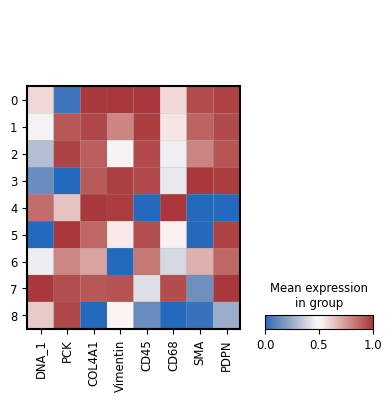

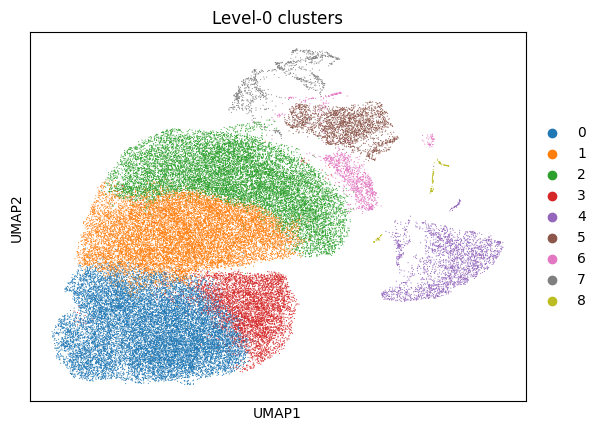

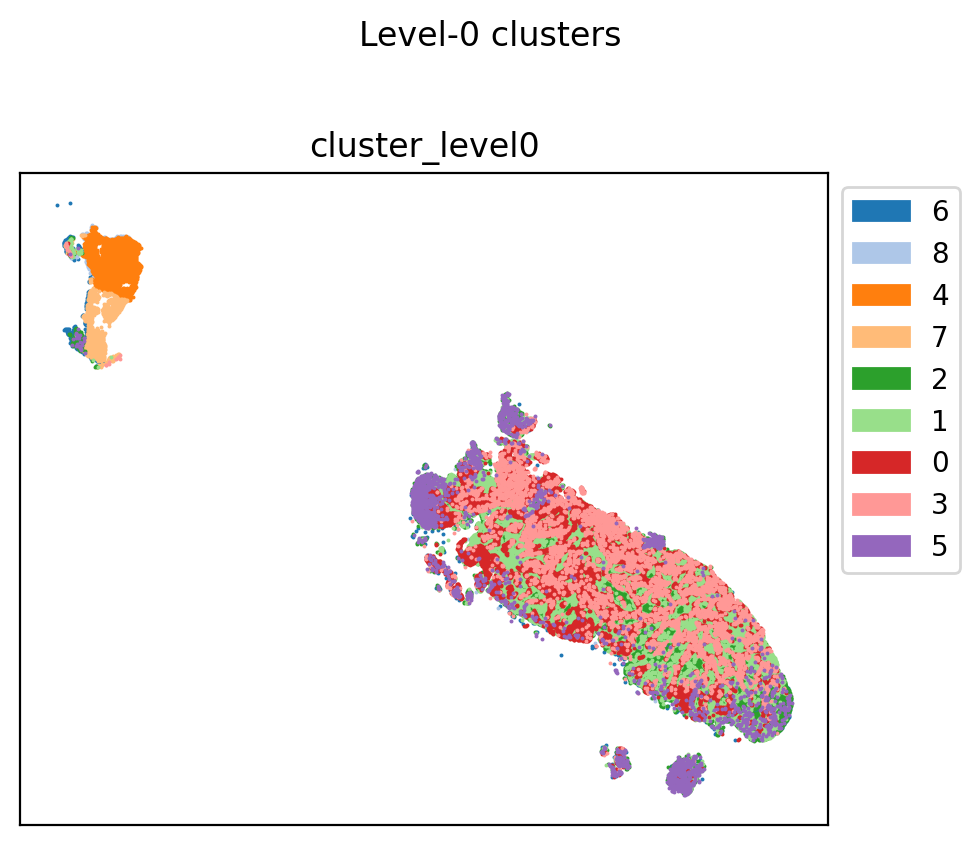

In [5]:
sv.pl.plot_cluster_heatmap(adata_clustered, level0_markers, cluster_key="cluster_level0")
plt.show()
plt.close("all")

if "X_umap" in adata_clustered.obsm:
    import scanpy as sc

    sc.pl.umap(adata_clustered, color="cluster_level0", title="Level-0 clusters")
    plt.close("all")

safe_spatial_scatter(adata_clustered, "cluster_level0", "Level-0 clusters")


## Overlay Level-0 Clusters On The Original Image

Set `RUN_LEVEL0_IMAGE_OVERLAY = True` in an interactive Jupyter session to open Napari/scimap with cluster labels overlaid on the original image. Use this view to decide the biological identity of each cluster before annotating.


In [6]:
RUN_LEVEL0_IMAGE_OVERLAY = False
review_on_original_image(
    adata_clustered,
    label="cluster_level0",
    image_path=ORIGINAL_IMAGE_PATH,
    run=RUN_LEVEL0_IMAGE_OVERLAY,
)


Set run=True in this cell to open the original-image overlay viewer.


## Assign Level-0 Identities

Enter one label per level-0 cluster. Press Enter to keep the current cluster ID as the label.



Enter annotation for each cluster. Press Enter to keep the current label.



,cluster,annotation,n_cells
0,0,immune,15484
1,1,tumour,12847
2,2,tumour,11997
3,3,fibroblast,4918
4,4,artifact,2298
5,5,tumour,2277
6,6,tumour,1095
7,7,artifact,894
8,8,artifact,122


,n_cells
annotation_level0,
tumour,28216
immune,15484
fibroblast,4918
artifact,3314


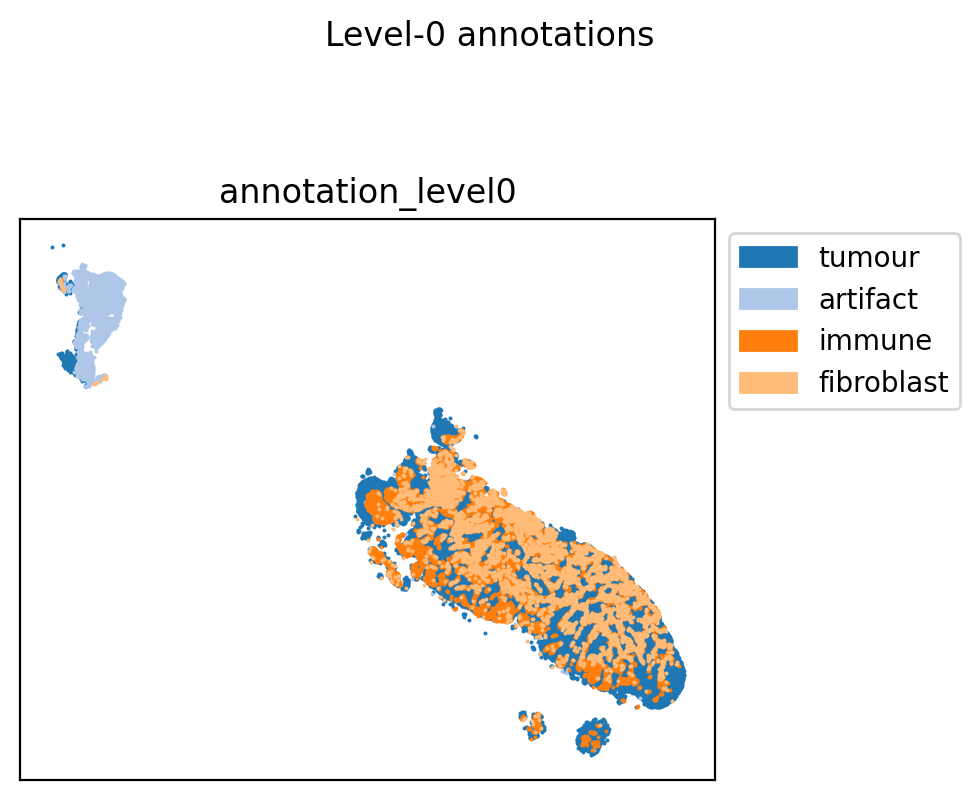

In [7]:
adata_clustered, level0_annotation_map = sv.tl.annotate_interactive(
    adata_clustered,
    cluster_key="cluster_level0",
    new_key="annotation_level0",
)
adata_clustered.obs["annotation_level0"] = adata_clustered.obs["annotation_level0"].astype(str)

level0_annotation_review = make_annotation_review_table(
    adata_clustered,
    cluster_key="cluster_level0",
    mapping=level0_annotation_map,
)
display(level0_annotation_review)
show_counts(adata_clustered.obs["annotation_level0"], "annotation_level0")
safe_spatial_scatter(adata_clustered, "annotation_level0", "Level-0 annotations")


## Overlay Level-0 Annotations On The Original Image

Re-open the image overlay after annotation to catch mislabels before doing any refinement.


In [8]:
RUN_LEVEL0_ANNOTATION_OVERLAY = False
review_on_original_image(
    adata_clustered,
    label="annotation_level0",
    image_path=ORIGINAL_IMAGE_PATH,
    run=RUN_LEVEL0_ANNOTATION_OVERLAY,
)


Set run=True in this cell to open the original-image overlay viewer.


## Optional: Choose Populations To Recluster

Use this when broad level-0 identities still contain biologically distinct subtypes. Set `REFINE_LABELS` to one or more values from `annotation_level0`; each label will be subset, reclustered with its own marker panel and per-label clustering parameters, reviewed, annotated, and merged back.

Subsets are taken from the full AnnData before reclustering, so each refinement panel can use markers that were not included in the level-0 clustering panel.


In [9]:
REFINE_LABELS = ["tumour", "immune", "fibroblast"]  # Example: ["tumour", "immune", "fibroblast"]

# Use either one value for all subsets or a dictionary keyed by REFINE_LABELS.
REFINE_RESOLUTION = {
    "tumour": 0.5,
    "immune": 0.3,
    "fibroblast": 0.3,
}
REFINE_N_NEIGHBORS = 10
REFINE_N_PCS = 10


def refine_setting(setting, label, default):
    if isinstance(setting, dict):
        return setting.get(label, default)
    return setting


if isinstance(REFINE_LABELS, str):
    refine_labels = [REFINE_LABELS]
else:
    refine_labels = list(REFINE_LABELS or [])

refinement_compartments = {}
refine_markers_by_label = {}
refine_configs = {}

if not refine_labels:
    print("No refinement requested. Add labels to REFINE_LABELS to recluster broad annotations.")
else:
    adata_refinement_base = adata.copy()
    adata_refinement_base.obs["cluster_level0"] = adata_clustered.obs["cluster_level0"].reindex(
        adata_refinement_base.obs_names
    ).astype(str)
    adata_refinement_base.obs["annotation_level0"] = adata_clustered.obs["annotation_level0"].reindex(
        adata_refinement_base.obs_names
    ).astype(str)

    for label in refine_labels:
        compartment = sv.tl.subset_cells(adata_refinement_base, "annotation_level0", label)
        if compartment.n_obs == 0:
            print(f"Skipping {label!r}: no cells found in annotation_level0.")
            continue

        marker_panel = REFINEMENT_MARKERS.get(label)
        if marker_panel is None:
            marker_panel = level0_markers
            print(f"{label!r}: no entry in REFINEMENT_MARKERS; using LEVEL0_MARKERS.")

        refine_markers = present(markers, marker_panel)
        refine_config = make_clustering_config(
            refine_markers,
            resolution=float(refine_setting(REFINE_RESOLUTION, label, 0.3)),
            n_neighbors=int(refine_setting(REFINE_N_NEIGHBORS, label, 10)),
            n_pcs=int(refine_setting(REFINE_N_PCS, label, 10)),
        )

        refinement_compartments[label] = compartment
        refine_markers_by_label[label] = refine_markers
        refine_configs[label] = refine_config

        print(f"{label}: {compartment.n_obs:,} cells")
        print(refine_config)


tumour: 28,216 cells
ClusteringConfig(markers=['DNA_1', 'PCK', 'CD45', 'CD68', 'SMA', 'PDPN'], resolution=0.5, n_neighbors=10, n_pcs=5, scale=True)
immune: 15,484 cells
ClusteringConfig(markers=['DNA_1', 'PCK', 'CD45', 'CD68', 'COL4A1', 'SMA', 'PDPN'], resolution=0.3, n_neighbors=10, n_pcs=6, scale=True)
fibroblast: 4,918 cells
ClusteringConfig(markers=['DNA_1', 'PCK', 'CD45', 'CD68', 'COL4A1', 'SMA', 'PDPN'], resolution=0.3, n_neighbors=10, n_pcs=6, scale=True)


## Optional: Run Subset Clustering


In [10]:
subclustered_by_label = {}

if refinement_compartments:
    for label, compartment in refinement_compartments.items():
        print(f"Clustering {label}...")
        compartment = sv.pp.zscore_normalize(compartment.copy())
        subclustered = sv.tl.cluster_cells(compartment, refine_configs[label])
        subclustered.obs["cluster_level1"] = subclustered.obs["leiden"].astype(str)
        subclustered.obs["refinement_label"] = label
        subclustered_by_label[label] = subclustered
        show_counts(subclustered.obs["cluster_level1"], f"{label} cluster_level1")
else:
    print("Subset clustering skipped.")


Clustering tumour...


,n_cells
tumour cluster_level1,
0,3815
1,2694
2,2622
3,2503
4,2431
5,2329
6,1951
7,1833
8,1770


Clustering immune...


,n_cells
immune cluster_level1,
0,4056
1,3322
2,3031
3,2573
4,2388
5,97
6,17


Clustering fibroblast...


,n_cells
fibroblast cluster_level1,
0,1083
1,1049
2,947
3,787
4,615
5,345
6,81
7,11


## Optional: Review Subclusters

Review each refined heatmap, UMAP, and spatial scatter, then overlay subclusters on the original image before assigning refined identities.



tumour subclusters


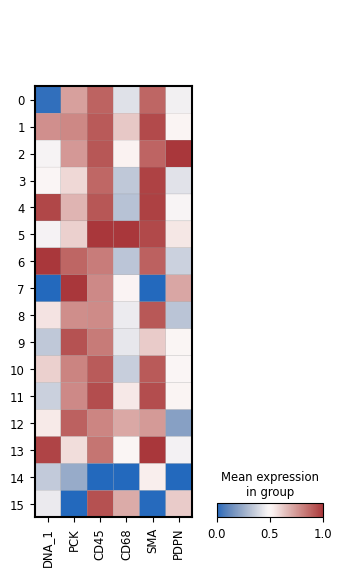

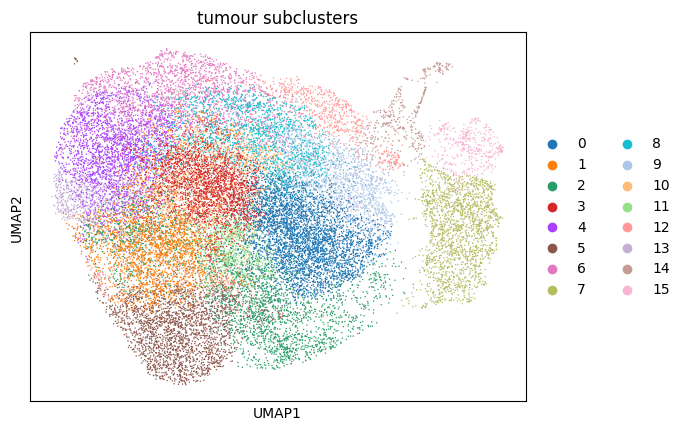

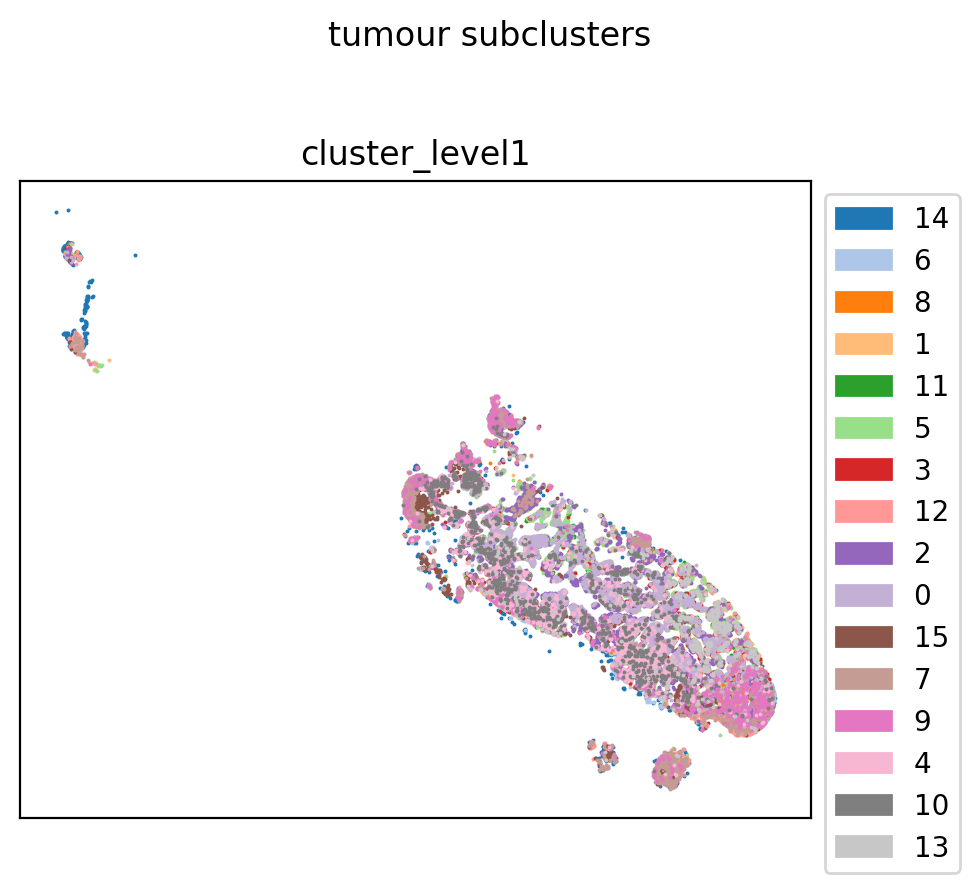


immune subclusters


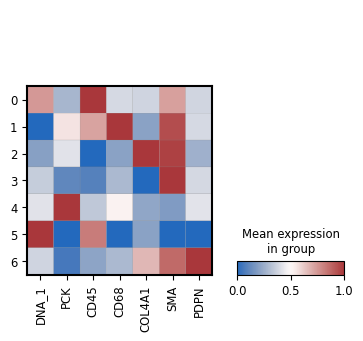

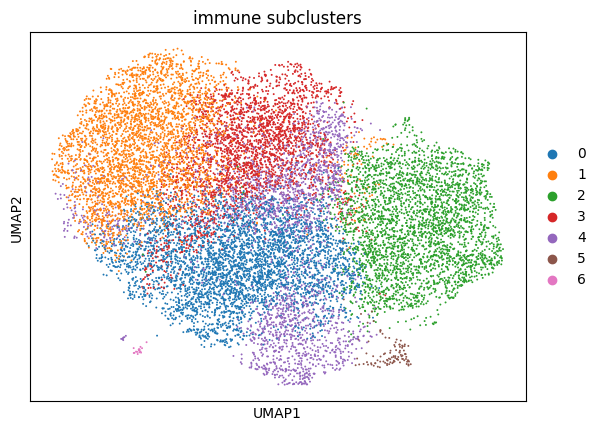

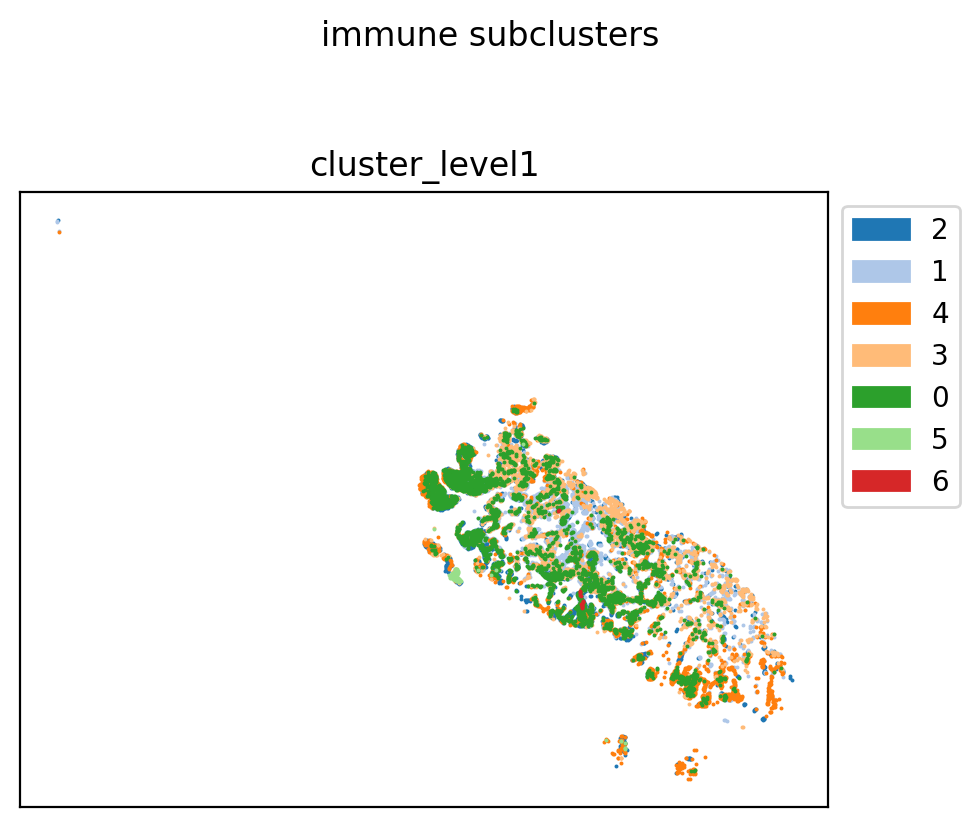


fibroblast subclusters


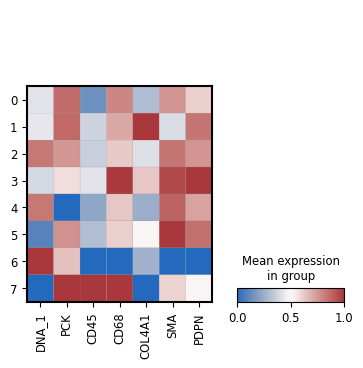

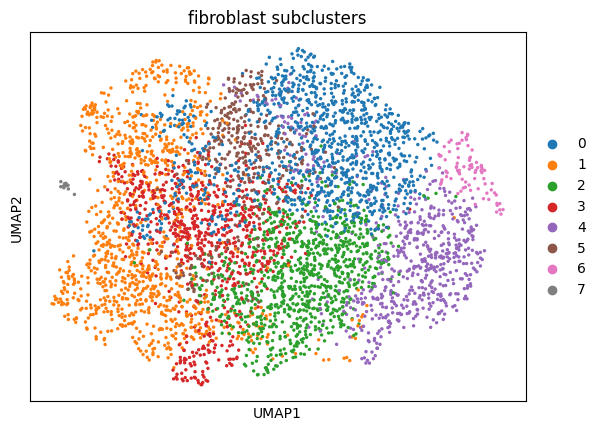

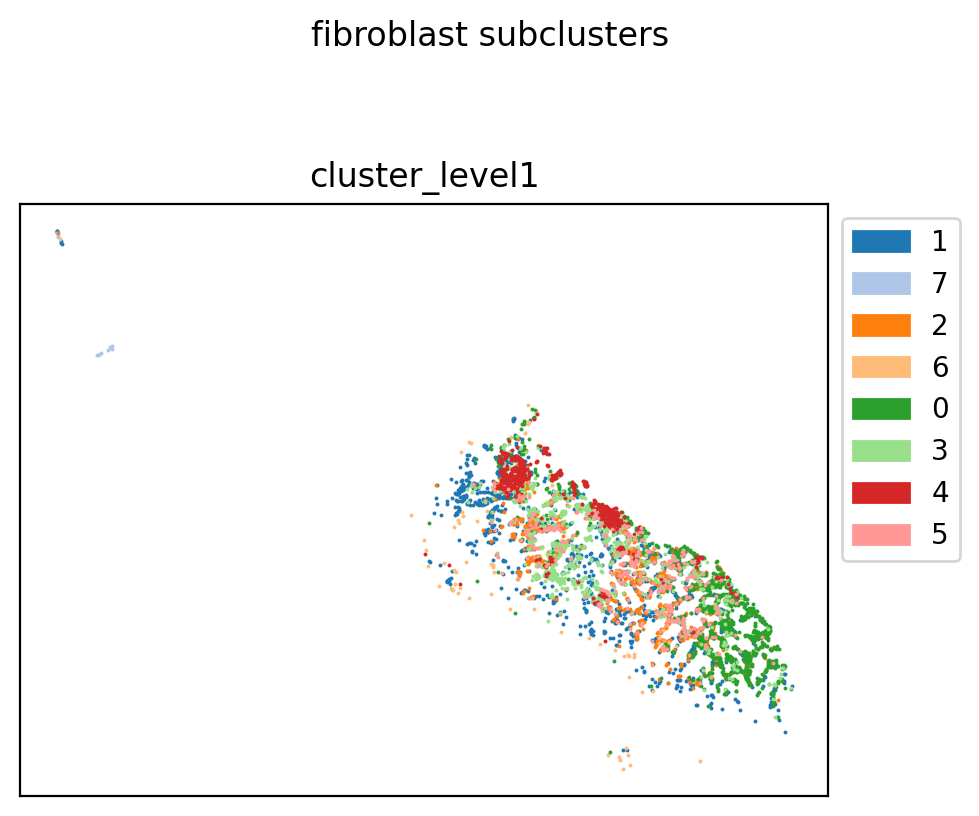

In [11]:
if subclustered_by_label:
    for label, subclustered in subclustered_by_label.items():
        refine_markers = refine_markers_by_label[label]
        print()
        print(f"{label} subclusters")
        sv.pl.plot_cluster_heatmap(subclustered, refine_markers, cluster_key="cluster_level1")
        plt.show()
        plt.close("all")

        if "X_umap" in subclustered.obsm:
            import scanpy as sc

            sc.pl.umap(subclustered, color="cluster_level1", title=f"{label} subclusters")
            plt.close("all")

        safe_spatial_scatter(subclustered, "cluster_level1", f"{label} subclusters")
else:
    print("No subclusters to review.")


## Optional: Overlay Subclusters On The Original Image


In [12]:
RUN_LEVEL1_IMAGE_OVERLAY = False
if subclustered_by_label:
    for label, subclustered in subclustered_by_label.items():
        print()
        print(f"{label} image overlay")
        review_on_original_image(
            subclustered,
            label="cluster_level1",
            image_path=ORIGINAL_IMAGE_PATH,
            run=RUN_LEVEL1_IMAGE_OVERLAY,
        )
else:
    print("No subclusters to overlay.")



tumour image overlay
Set run=True in this cell to open the original-image overlay viewer.

immune image overlay
Set run=True in this cell to open the original-image overlay viewer.

fibroblast image overlay
Set run=True in this cell to open the original-image overlay viewer.


## Optional: Assign Refined Identities And Merge

If subclustering was run, enter one label per refined subcluster for each selected population. Cells outside those populations keep their level-0 annotation.


In [ ]:
adata_final = adata.copy()
adata_final.obs["cluster_level0"] = adata_clustered.obs["cluster_level0"].reindex(
    adata_final.obs_names
).astype(str)
adata_final.obs["annotation_level0"] = adata_clustered.obs["annotation_level0"].reindex(
    adata_final.obs_names
).astype(str)
adata_final.obs["annotation_level1"] = adata_final.obs["annotation_level0"].astype(str)

refined_for_merge = {}
level1_annotation_maps = {}

if subclustered_by_label:
    for label, subclustered in subclustered_by_label.items():
        print()
        print(f"Annotating {label} subclusters")
        subclustered, annotation_map = sv.tl.annotate_interactive(
            subclustered,
            cluster_key="cluster_level1",
            new_key="annotation",
        )
        subclustered.obs["annotation"] = subclustered.obs["annotation"].astype(str)
        level1_annotation_maps[label] = annotation_map
        refined_for_merge[label] = subclustered

        level1_annotation_review = make_annotation_review_table(
            subclustered,
            cluster_key="cluster_level1",
            mapping=annotation_map,
        )
        level1_annotation_review.insert(0, "refinement_label", label)
        display(level1_annotation_review)

    adata_final = sv.tl.merge_refinements(
        adata_final,
        refined_for_merge,
        new_key="annotation_level1",
    )
else:
    print("No refined annotations to merge.")

show_counts(adata_final.obs["annotation_level1"], "annotation_level1")
safe_spatial_scatter(adata_final, "annotation_level1", "Final annotations")


## Optional: Overlay Final Annotations On The Original Image


In [ ]:
RUN_FINAL_IMAGE_OVERLAY = False
review_on_original_image(
    adata_final,
    label="annotation_level1",
    image_path=ORIGINAL_IMAGE_PATH,
    run=RUN_FINAL_IMAGE_OVERLAY,
)


## Save Annotation Table


In [ ]:
annotation_cols = present(
    adata_final.obs.columns,
    ["cluster_level0", "annotation_level0", "annotation_level1"],
)
adata_final.obs[annotation_cols].to_csv(ANNOTATION_PATH)
print(f"Wrote {ANNOTATION_PATH.relative_to(ROOT)}")
